In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Generate synthetic dataset
np.random.seed(42)
num_samples = 1000

age = np.random.randint(21, 70, size=num_samples)
annual_income = np.random.normal(55000, 20000, size=num_samples).clip(15000, 150000)
debt_to_income_ratio = np.random.uniform(0.1, 0.7, size=num_samples)
missed_payments = np.random.poisson(lam=0.5, size=num_samples)
credit_utilization = np.random.uniform(0.05, 0.95, size=num_samples)

# Ground truth formula for risk
risk_score = (debt_to_income_ratio * 4) + (missed_payments * 1.5) + (credit_utilization * 3) - (annual_income / 40000) - (age / 100)
threshold = np.percentile(risk_score, 75)
default_status = (risk_score >= threshold).astype(int)

df = pd.DataFrame({
    'Age': age,
    'Annual_Income': annual_income,
    'Debt_to_Income_Ratio': debt_to_income_ratio,
    'Missed_Payments': missed_payments,
    'Credit_Utilization': credit_utilization,
    'Default': default_status
})

# Display first 5 rows cleanly in Jupyter
df.head()

,Age,Annual_Income,Debt_to_Income_Ratio,Missed_Payments,Credit_Utilization,Default
0,59,58479.326583,0.324078,1,0.614971,0
1,49,73157.438945,0.173426,1,0.632712,0
2,35,54824.188874,0.541303,0,0.809380,0
3,63,64028.223973,0.241515,0,0.342431,0
4,28,71317.032410,0.322853,0,0.668566,0


In [3]:
X = df.drop(columns=['Default'])
y = df['Default']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 800 samples
Testing set size: 200 samples



==================== Logistic Regression ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       150
           1       1.00      0.96      0.98        50

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200


==================== Random Forest ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       150
           1       0.98      0.90      0.94        50

    accuracy                           0.97       200
   macro avg       0.97      0.95      0.96       200
weighted avg       0.97      0.97      0.97       200



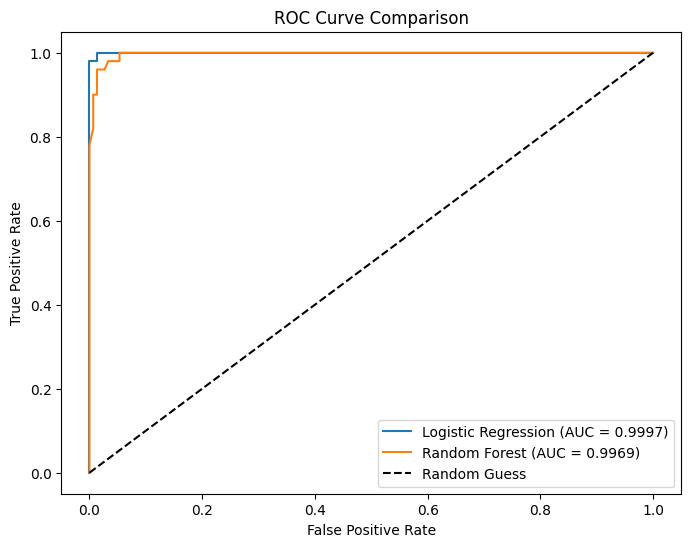

In [4]:
models = {
    "Logistic Regression": (LogisticRegression(random_state=42), X_train_scaled, X_test_scaled),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test)
}

plt.figure(figsize=(8, 6))

for name, (model, train_data, test_data) in models.items():
    # Train
    model.fit(train_data, y_train)
    
    # Predict
    preds = model.predict(test_data)
    probs = model.predict_proba(test_data)[:, 1]
    
    # Print Metrics
    print(f"\n==================== {name} ====================")
    print("Classification Report:")
    print(classification_report(y_test, preds))
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

# Format ROC Curve Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [5]:
import pickle

# Bundle the model and the fitted scaler together
pipeline = {
    "model": models["Logistic Regression"][0],
    "scaler": scaler
}

# Save it to a local file
with open("model_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model successfully saved as model_pipeline.pkl!")

Model successfully saved as model_pipeline.pkl!
